# Image Processing SoSe 2026 - Assignment - 08

### Deadline is 18.06.2026 at 11:55 a.m.

#### Students: Fabio Herrmann & Julius Böhm

Please solve the assignments together with a partner.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission.

In [65]:
# display the plots inside the notebook
%matplotlib inline

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
from skimage.data import chelsea
from skimage.color import rgb2gray
from scipy.fft import dctn as scipy_dctn, idctn as scipy_idctn

pylab.rcParams['figure.figsize'] = (12, 12)   # This makes the plot bigger

# Exercise 1 - 2D DCT - 4 Points
Transform a picture with 2D DCT (discrete cosine transform), which you must implement manually using DCT-II.
For the 2D-DCT, perform two 1D-DCT-transformations. Therefore, implement a method which returns a normalized DCT-II matrix. Plot a normalized 16x16 DCT-II-matrix (with colors reflecting the values in the matrix).

In [67]:
def gen_dct_ii_matrix(N):
    k = np.arange(N).reshape(N, 1)
    n = np.arange(N).reshape(1, N)
    
    C = np.cos(np.pi * k * (2 * n + 1) / (2 * N))
    
    alpha = np.ones((N, 1)) * np.sqrt(2 / N)
    alpha[0] = np.sqrt(1 / N)
    
    return alpha * C

print("DCT-II matrix for N=8:")
print(gen_dct_ii_matrix(16))

DCT-II matrix for N=8:
[[ 0.25        0.25        0.25        0.25        0.25        0.25
   0.25        0.25        0.25        0.25        0.25        0.25
   0.25        0.25        0.25        0.25      ]
 [ 0.35185093  0.3383295   0.31180625  0.27330047  0.2242919   0.16666391
   0.10263113  0.03465429 -0.03465429 -0.10263113 -0.16666391 -0.2242919
  -0.27330047 -0.31180625 -0.3383295  -0.35185093]
 [ 0.34675996  0.2939689   0.19642374  0.06897484 -0.06897484 -0.19642374
  -0.2939689  -0.34675996 -0.34675996 -0.2939689  -0.19642374 -0.06897484
   0.06897484  0.19642374  0.2939689   0.34675996]
 [ 0.3383295   0.2242919   0.03465429 -0.16666391 -0.31180625 -0.35185093
  -0.27330047 -0.10263113  0.10263113  0.27330047  0.35185093  0.31180625
   0.16666391 -0.03465429 -0.2242919  -0.3383295 ]
 [ 0.32664074  0.13529903 -0.13529903 -0.32664074 -0.32664074 -0.13529903
   0.13529903  0.32664074  0.32664074  0.13529903 -0.13529903 -0.32664074
  -0.32664074 -0.13529903  0.13529903  0.32664

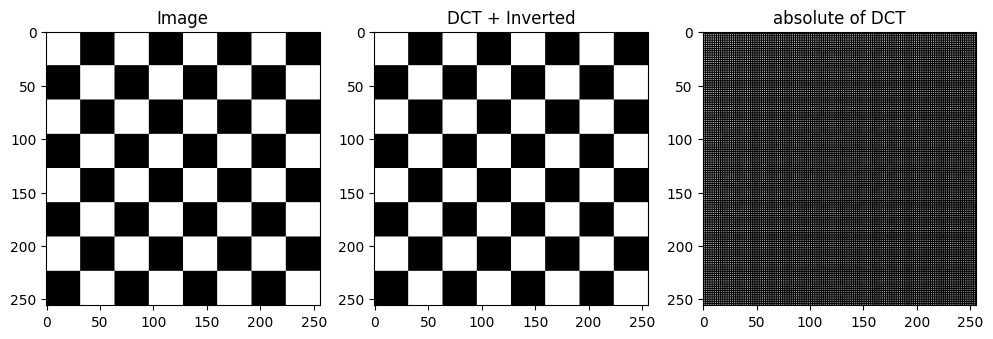

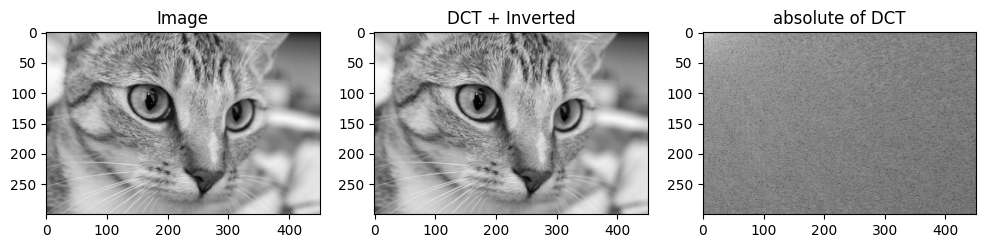

In [68]:
def dct2d(img):
    """
    Returns the 2d discrete cosine transformation
    """

    h, w = img.shape
    
    C_h = gen_dct_ii_matrix(h)
    C_w = gen_dct_ii_matrix(w)
    
    dct_img = C_h @ img @ C_w.T
    
    return dct_img

def inv_dct2d(img):
    """
    Returns the 2d inverse discrete cosine transformation
    """

    h, w = img.shape
    
    C_h = gen_dct_ii_matrix(h)
    C_w = gen_dct_ii_matrix(w)
    
    img_recon = C_h.T @ img @ C_w
    
    return img_recon

def chess_board(n=8, field_size=32):
    board = np.zeros((n*field_size, n*field_size))
    s = field_size
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                board[i*s:(i+1)*s, j*s:(j+1)*s] = 1
    return board

for pic in [chess_board(), rgb2gray(chelsea())/255.0]:
    plt.subplot(231)
    plt.title("Image")
    plt.imshow(pic, cmap='gray')
    plt.subplot(232)
    plt.title("DCT + Inverted")
    plt.imshow(inv_dct2d(dct2d(pic)), cmap='gray')
    plt.subplot(233)
    plt.title("absolute of DCT")
    plt.imshow(np.log10(1e-9 + np.abs(dct2d(pic))), cmap='gray')
    plt.show()

# Exercise 2 - 1 Point: (Manual calculation, no code needed.)

Given is a signal `[5,10,12]`. Now you have to mirror the signal as in the lectures (resulting in a signal of length 5) and perform a DFT. Please write down all coefficients in the frequency spectrum. What do you see (one sentence)?

$$
s = [5, 10, 12] \\
x = [5, 10, 12, 12, 10] \\
$$

$$
\begin{matrix}
X[k] = &  ∑^{N−1}_{n=0} ​x[n] ⋅ e^{−j \frac{2π}{N} ​kn} \\
\ \ \ \ \ \ \ \ \ = &  x[0] + x[1] e^{−j \frac{2π}{5} ​k} + x[2] e^{−j \frac{4π}{5} ​k} + x[3] e^{−j \frac{6π}{5} ​k} + x[4] e^{−j \frac{8π}{5} ​k} \\
\ \ \ \ \ \ \ \ \ = &  5 + 10 e^{−j \frac{2π}{5} ​k} + 12 e^{−j \frac{4π}{5} ​k} + 12 e^{-j \frac{6π}{5} ​k} + 10 e^{-j \frac{8π}{5} ​k} \\
                    & \\
\ \ \ \ \ \ \ \ \ = &   (5 + 10 ⋅ cos(−j \frac{2π}{5} ​k) + 12 ⋅ cos(−j \frac{4π}{5} ​k) + 12 ⋅ cos(-j \frac{6π}{5} ​k) + 10 ⋅ cos(-j \frac{8π}{5} ​k)) \\
                    & -i(10 ⋅ sin(−j \frac{2π}{5} ​k) + 12 ⋅ sin(−j \frac{4π}{5} ​k) + 12 ⋅ sin(-j \frac{6π}{5} ​k) + 10 ⋅ sin(-j \frac{8π}{5} ​k)) \\
                    & \\
\ \ \ \ \ \ \ \ \ = &   (5 + 10 ⋅ cos(j \frac{2π}{5} ​k) + 12 ⋅ cos(j \frac{4π}{5} ​k) + 12 ⋅ cos(j \frac{4π}{5} ​k) + 10 ⋅ cos(j \frac{2π}{5} ​k)) \\
                    & -i(10 ⋅ (sin(−j \frac{2π}{5} ​k)) + 12 ⋅ sin(−j \frac{4π}{5} ​k) - 12 ⋅ sin(-j \frac{4π}{5} ​k) - 10 ⋅ sin(-j \frac{2π}{5} ​k)) \\
                    & \\
\ \ \ \ \ \ \ \ \ = & (5 + 2 ⋅ 10 ⋅ cos(j \frac{2π}{5} ​k) + 2 ⋅ 12 ⋅ cos(j \frac{4π}{5} ​k)) + i\ 0 \\
\ \ \ \ \ \ \ \ \ = & 5 + 20 ⋅ cos(\frac{2π}{5} ​k) + 24 ⋅ cos(\frac{4π}{5} ​k) \\
\end{matrix} \\
$$

$$
X = [49, -8,236, -3,763, -3,763, -8,236] \\
S = [49, -8,236, -3,763]
$$

Die Berechnung wurde durch die Spiegelung wesentlich vereinfacht, da die komplexen Imaginärteile und damit die Sinus-Berechnungen komplett wegfallen und die Lösung damit zu einer reinen Cosinus-Summe wird. 

Das Ergebnis enthält ebenfalls gespiegelte Werte, die sich leicht abschneiden lassen, indem man die Erweiterung durch Spiegelung zu Beginn einfach "umkehrt", also die zu Beginn eingefügten Werte am Ende einfach löscht.

# Exercise 3 - High and Low Pass filter with 2D DCT - 5 Points

Implement the `high_pass` and `low_pass` functions which work on the frequency spectrum of a 2D-DCT
transformed image. Apply the filters to both the chessboard and cat image and transform the
result back into image space.

Show the spectrum before and after filtering as well as the resulting images after backtransformation
into image space.

In [69]:
def low_pass(img_ft, n):
    """Removes the low frequencies"""
    ft = img_ft.copy()
    h, w = ft.shape

    Y, X = np.ogrid[:h, :w]
    ft[X + Y >= n] = 0

    return ft

def high_pass(img_ft, n):
    """Removes the high frequencies (keeps low-frequency corner blocks of size n)."""
    ft = img_ft.copy()
    h, w = ft.shape
    
    Y, X = np.ogrid[:h, :w]
    ft[X + Y < n] = 0
    
    return ft
    
def inv_dct_and_plot(img_ft):
    plt.imshow(inv_dct2d(img_ft), cmap='gray')
    plt.show()

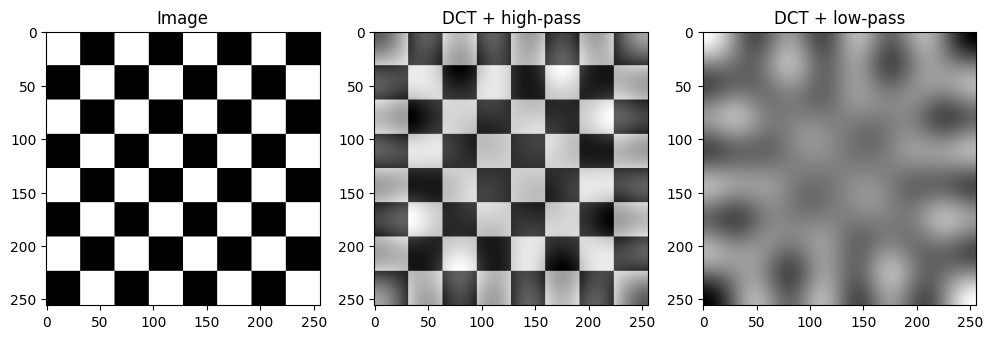

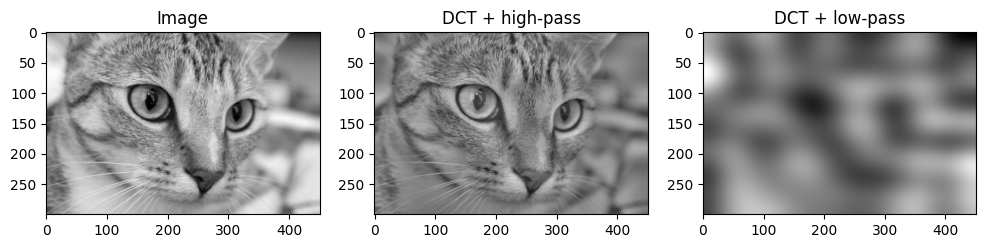

In [70]:
for pic in [chess_board(), rgb2gray(chelsea())/255.0]:
    plt.subplot(231)
    plt.title("Image")
    plt.imshow(pic, cmap='gray')
    plt.subplot(232)
    plt.title("DCT + high-pass")
    plt.imshow(inv_dct2d(high_pass(dct2d(pic), 12)), cmap='gray')
    plt.subplot(233)
    plt.title("DCT + low-pass")
    plt.imshow(inv_dct2d(low_pass(dct2d(pic), 12)), cmap='gray')
    plt.show()

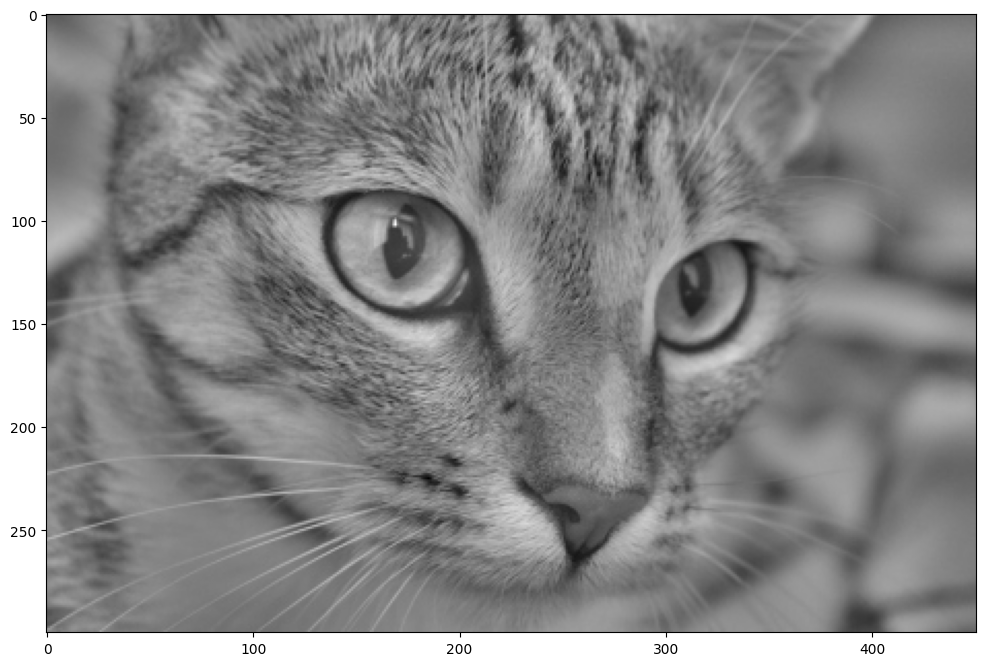

In [71]:
img = rgb2gray(chelsea() / 255)
# remove the low frequencies
chelsea_high_freq = high_pass(dct2d(img), 12)
inv_dct_and_plot(chelsea_high_freq)

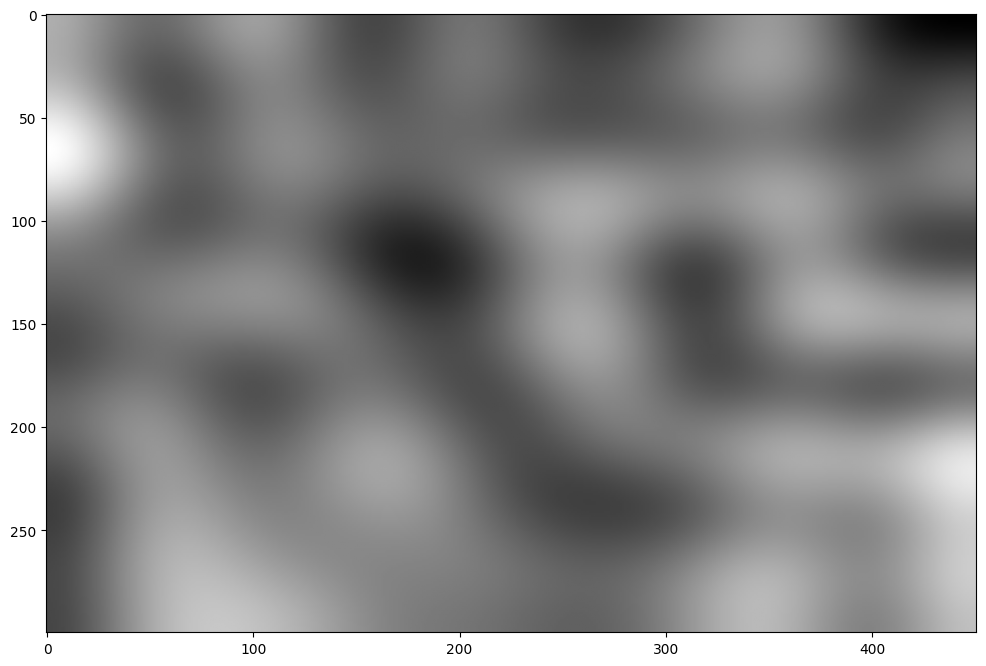

In [72]:
# remove the high frequencies
chelsea_low_freq = low_pass(dct2d(img), 12)
inv_dct_and_plot(chelsea_low_freq)